# Capítulo 6 — Redes de Filas com Múltiplas Classes

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from line_solver.api.pfqn import pfqn_mvamx, pfqn_bs
from line_solver import (Network, Queue, Delay, Source, Sink, ClosedClass, OpenClass,
                         Exp, SchedStrategy, SolverMVA, GlobalConstants, VerboseLevel)

GlobalConstants.setVerbose(VerboseLevel.SILENT)
STATIONS = ['CPU', 'D1', 'D2']


In [2]:
def _build_mixed_net(lam, L, N, Z, snames=None):
    lam, L, N, Z = (np.asarray(x, float) for x in (lam, L, N, Z))
    M, R = L.shape
    is_open = np.isinf(N)
    if snames is None:
        snames = [f'S{i}' for i in range(M)]

    model    = Network('Mixed')
    stations = [Queue(model, nm, SchedStrategy.PS) for nm in snames]

    has_open = bool(np.any(is_open))
    src = Source(model, 'Src') if has_open else None
    snk = Sink(model,   'Snk') if has_open else None

    classes, think_nodes = [], []
    for r in range(R):
        if is_open[r]:
            cls = OpenClass(model, f'C{r}')
            src.setArrival(cls, Exp(lam[r]))
            think_nodes.append(None)
        elif Z[r] > 0:
            think = Delay(model, f'Think{r}')
            cls   = ClosedClass(model, f'C{r}', int(N[r]), think)
            think.setService(cls, Exp(1.0 / Z[r]))
            think_nodes.append(think)
        else:
            cls = ClosedClass(model, f'C{r}', int(N[r]), stations[0])
            think_nodes.append(None)
        classes.append(cls)

    for r, cls in enumerate(classes):
        for i, st in enumerate(stations):
            d = L[i, r]
            st.setService(cls, Exp(1.0 / d) if d > 0 else Exp(1e9))

    P = model.initRoutingMatrix()
    for r, cls in enumerate(classes):
        active = [stations[i] for i in range(M) if L[i, r] > 0]
        if is_open[r]:
            path = [src] + active + [snk]
        elif Z[r] > 0:
            t    = think_nodes[r]
            path = [t] + active + [t]
        else:
            path = ([stations[0]]
                    + [s for s in active if s is not stations[0]]
                    + [stations[0]])
        for a, b in zip(path, path[1:]):
            P.set(cls, cls, a, b, 1.0)

    model.link(P)
    return model


In [3]:
def print_results(label, XN, UN, CN, Z, classes, stations, iters=None):
    xn = np.ravel(XN)
    R  = len(classes)
    if iters is not None:
        label = label + "  [" + str(iters) + " iter.]"
    sep = "-" * 62
    print()
    print(sep)
    print("  " + label)
    print(sep)
    print(f"{'Classe':<12}  {'X (t/s)':>10}  {'R (s)':>10}  {'C (s)':>10}")
    print("-" * 48)
    for r in range(R):
        R_r = float(CN[:, r].sum())
        C_r = R_r + float(Z[r])
        print(f"{classes[r]:<12}  {float(xn[r]):>10.5f}  {R_r:>10.5f}  {C_r:>10.5f}")
    print()
    u_header = f"{'Estacao':<10}  {'U_total':>8}" + "".join(f"  {'U_'+c:>8}" for c in classes)
    print(u_header)
    print("-" * len(u_header))
    for i, st in enumerate(stations):
        u_tot = float(UN[i, :].sum())
        row = f"{st:<10}  {u_tot:>8.4f}" + "".join(f"  {float(UN[i, r]):>8.4f}" for r in range(R))
        print(row)
    print()


---
#### 6.1) Consider the transaction system of Sec. 6.2. Calculate the performance measures of that model using the approximate MVA algorithm. Assume that the stopping criterion is to have a maximum difference of 0.001 for successive values of $n_{i,r}$​. Suppose now that the multiprogramming level of the update class is tripled. Recalculate the model's results using the exact and approximate techniques. Compare the computational effort required by the two algorithms.

In [4]:
L2 = np.array([[0.105, 0.375],   # CPU: D_Q = 105 ms, D_U = 375 ms
               [0.180, 0.480],   # D1:  D_Q = 180 ms, D_U = 480 ms
               [0.000, 0.240]])  # D2:  D_Q =   0 ms, D_U = 240 ms

lam2 = np.array([0.0, 0.0])
Z2   = np.array([0.0, 0.0])
CL2  = ['Q', 'U']


In [5]:
N2_orig = np.array([3.0, 1.0])

XN_a1, _, UN_a1, CN_a1, it_a1 = pfqn_bs(L2, N2_orig, Z2, tol=1e-3)
print_results("N=[3,1] | pfqn_bs AMVA (tol=0.001)",
              XN_a1, UN_a1, CN_a1, Z2, CL2, STATIONS, iters=it_a1)

XN_e1, _, UN_e1, CN_e1, _ = pfqn_mvamx(lam2, L2, N2_orig, Z2)
print_results("N=[3,1] | MVA exato (pfqn_mvamx)",
              XN_e1, UN_e1, CN_e1, Z2, CL2, STATIONS)

# N_Q=3, N_U=3 (N_U triplicado)
N2_trip = np.array([3.0, 3.0])

XN_a3, _, UN_a3, CN_a3, it_a3 = pfqn_bs(L2, N2_trip, Z2, tol=1e-3)
print_results("N=[3,3] | pfqn_bs AMVA (tol=0.001)",
              XN_a3, UN_a3, CN_a3, Z2, CL2, STATIONS, iters=it_a3)

XN_e3, _, UN_e3, CN_e3, _ = pfqn_mvamx(lam2, L2, N2_trip, Z2)
print_results("N=[3,3] | MVA exato (pfqn_mvamx)",
              XN_e3, UN_e3, CN_e3, Z2, CL2, STATIONS)

states_orig = (int(N2_orig[0]) + 1) * (int(N2_orig[1]) + 1)
states_trip = (int(N2_trip[0]) + 1) * (int(N2_trip[1]) + 1)
print(f"Iteracoes AMVA:       N_U=1 -> {it_a1}   |   N_U=3 -> {it_a3}")
print(f"Estados (MVA exato):  N_U=1 -> {states_orig}      |   N_U=3 -> {states_trip}")



--------------------------------------------------------------
  N=[3,1] | pfqn_bs AMVA (tol=0.001)  [10 iter.]
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                3.99688     0.75059     0.75059
U                0.40692     2.45747     2.45747

Estacao      U_total       U_Q       U_U
----------------------------------------
CPU           0.5723    0.4197    0.1526
D1            0.9148    0.7194    0.1953
D2            0.0977    0.0000    0.0977


--------------------------------------------------------------
  N=[3,1] | MVA exato (pfqn_mvamx)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                4.09389     0.73280     0.73280
U                0.40933     2.44300     2.44300

Estacao      U_total       U_Q       U_U
---------------------

<br>
<br>

---

#### 6.2) In the example of the transaction system of Sec. 6.2 it is noted that query transactions only make use of disk 1, which increases its utilization and turns it into the bottleneck. Having observed this problem, the support analyst wants to know what would be the effect on performance if the I/O load due to query transactions were balanced among the two disks. Compare the results obtained with the current situation.

In [ ]:
L2_bal       = L2.copy()
L2_bal[1, 0] = 0.090   # D1, classe Q: 180 ms -> 90 ms
L2_bal[2, 0] = 0.090   # D2, classe Q:   0 ms -> 90 ms

XN_o, _, UN_o, CN_o, _ = pfqn_mvamx(lam2, L2,     N2_orig, Z2)
XN_b, _, UN_b, CN_b, _ = pfqn_mvamx(lam2, L2_bal, N2_orig, Z2)

print_results("Q2 — Original        (D_D1_Q=180 ms, D_D2_Q=  0 ms)",
              XN_o, UN_o, CN_o, Z2, CL2, STATIONS)
print_results("Q2 — E/S balanceada  (D_D1_Q= 90 ms, D_D2_Q= 90 ms)",
              XN_b, UN_b, CN_b, Z2, CL2, STATIONS)

R_Q_o = float(CN_o[:, 0].sum())
R_Q_b = float(CN_b[:, 0].sum())
R_U_o = float(CN_o[:, 1].sum())
R_U_b = float(CN_b[:, 1].sum())
print(f"Tempo de resposta Q:  original = {R_Q_o:.5f} s   balanceado = {R_Q_b:.5f} s   variacao = {(R_Q_b/R_Q_o - 1)*100:+.2f}%")
print(f"Tempo de resposta U:  original = {R_U_o:.5f} s   balanceado = {R_U_b:.5f} s   variacao = {(R_U_b/R_U_o - 1)*100:+.2f}%")



--------------------------------------------------------------
  Q2 — Original        (D_D1_Q=180 ms, D_D2_Q=  0 ms)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                4.09389     0.73280     0.73280
U                0.40933     2.44300     2.44300

Estacao      U_total       U_Q       U_U
----------------------------------------
CPU           0.5834    0.4299    0.1535
D1            0.9334    0.7369    0.1965
D2            0.0982    0.0000    0.0982


--------------------------------------------------------------
  Q2 — E/S balanceada  (D_D1_Q= 90 ms, D_D2_Q= 90 ms)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                5.24653     0.57181     0.57181
U                0.45612     2.19241     2.19241

Estacao      U_total       U_Q       U

#### 6.3) A computer system has a CPU and two disks, D1 and D2. The workload is divided into three classes: query (Q) transactions, update (U) transactions, and interactive (I) users. Table 6.12 gives the input parameters for these classes.

 $Class$ | $D_{cpu}$ | $D_{d1}$ | $D_{d2}$ | $N_r^{max}$ | $\lambda_r$ | $M_r$ | $Z_r$ |
|-------|------|-----|-----|------|----|----|----|
| Q     | 0.06 | 0.030 | 0.06 | 5 | 3.0 | -  | -  |
| U     | 0.10 | 0.030 | 0.09 | 3 | 1.5 | -  | -  |
| I     | 0.09 | 0.045 | 0.00 | 5 | - | 50 | 15 |


In [ ]:
L3 = np.array([[0.060, 0.100, 0.090],   # CPU
               [0.030, 0.030, 0.045],   # D1
               [0.060, 0.090, 0.000]])  # D2: D_Q=60ms, D_U=90ms, D_I=0ms

lam3 = np.array([3.0,    1.5,    0.0])    # Q: aberta lam=3.0; U: aberta lam=1.5; I: fechada
N3   = np.array([np.inf, np.inf, 50.0])   # Q,U: abertas (inf); I: M=50 terminais
Z3   = np.array([0.0,    0.0,   15.0])    # Z_I = 15 s
M_I  = 50
CL3  = ['Q', 'U', 'I']


a) What is the average response time for each class?

In [9]:
# 3a: modelo base
XN3a, _, UN3a, CN3a, _ = pfqn_mvamx(lam3, L3, N3, Z3)
xn3a = np.ravel(XN3a)

R_Q_a = float(CN3a[:, 0].sum())           # soma dos tempos de residencia
R_U_a = float(CN3a[:, 1].sum())           # ciclo batch (Z_U=0)
R_I_a = float(M_I / xn3a[2] - Z3[2])     # R_I = M_I/X_I - Z_I

print_results("Q3a — Modelo 3 classes (base, lambda_Q=3.0 t/s)",
              XN3a, UN3a, CN3a, Z3, CL3, STATIONS)
print("Tempos de resposta por classe:")
print(f"  R_Q = {R_Q_a:.5f} s  (aberta: soma dos tempos de residencia)")
print(f"  R_U = {R_U_a:.5f} s  (aberta: soma dos tempos de residencia)")
print(f"  R_I = {R_I_a:.5f} s  (interativo: M_I/X_I - Z_I = {M_I}/{xn3a[2]:.5f} - {int(Z3[2])})")



--------------------------------------------------------------
  Q3a — Modelo 3 classes (base, lambda_Q=3.0 t/s)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                3.00000     0.28719     0.28719
U                1.50000     0.43621     0.43621
I                3.26890     0.29566    15.29566

Estacao      U_total       U_Q       U_U       U_I
--------------------------------------------------
CPU           0.6242    0.1800    0.1500    0.2942
D1            0.2821    0.0900    0.0450    0.1471
D2            0.3150    0.1800    0.1350    0.0000

Tempos de resposta por classe:
  R_Q = 0.28719 s  (aberta: soma dos tempos de residencia)
  R_U = 0.43621 s  (aberta: soma dos tempos de residencia)
  R_I = 0.29566 s  (interativo: M_I/X_I - Z_I = 50/3.26890 - 15)


b) What is the impact on response time if the arrival rate of query transactions is increased by $95\%$?


In [10]:
# 3b: lambda_Q aumentada 95%
lam3b    = lam3.copy()
lam3b[0] = lam3[0] * 1.95   # 3.0 x 1.95 = 5.85 t/s

XN3b, _, UN3b, CN3b, _ = pfqn_mvamx(lam3b, L3, N3, Z3)
xn3b = np.ravel(XN3b)

R_Q_b = float(CN3b[:, 0].sum())
R_U_b = float(CN3b[:, 1].sum())
R_I_b = float(M_I / xn3b[2] - Z3[2])

print_results(f"Q3b — lambda_Q = {lam3b[0]:.2f} t/s (+95%)",
              XN3b, UN3b, CN3b, Z3, CL3, STATIONS)
print("Comparacao dos tempos de resposta (base -> +95%):")
print(f"  R_Q: {R_Q_a:.5f} -> {R_Q_b:.5f} s   delta = {R_Q_b - R_Q_a:+.5f} s  ({(R_Q_b/R_Q_a-1)*100:+.1f}%)")
print(f"  R_U: {R_U_a:.5f} -> {R_U_b:.5f} s   delta = {R_U_b - R_U_a:+.5f} s  ({(R_U_b/R_U_a-1)*100:+.1f}%)")
print(f"  R_I: {R_I_a:.5f} -> {R_I_b:.5f} s   delta = {R_I_b - R_I_a:+.5f} s  ({(R_I_b/R_I_a-1)*100:+.1f}%)")



--------------------------------------------------------------
  Q3b — lambda_Q = 5.85 t/s (+95%)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                5.85000     0.44263     0.44263
U                1.50000     0.68676     0.68676
I                3.23031     0.47839    15.47839

Estacao      U_total       U_Q       U_U       U_I
--------------------------------------------------
CPU           0.7917    0.3510    0.1500    0.2907
D1            0.3659    0.1755    0.0450    0.1454
D2            0.4860    0.3510    0.1350    0.0000

Comparacao dos tempos de resposta (base -> +95%):
  R_Q: 0.28719 -> 0.44263 s   delta = +0.15544 s  (+54.1%)
  R_U: 0.43621 -> 0.68676 s   delta = +0.25055 s  (+57.4%)
  R_I: 0.29566 -> 0.47839 s   delta = +0.18273 s  (+61.8%)


c) In the scenario with an increased arrival rate of query transactions, consider the following hardware upgrades and compare the performance improvements obtained with each one of them:

- replace disk D1 by one twice as fast.
- replace the CPU by one twice as fast.

In [11]:
# 3c: upgrades de hardware (a partir do cenario 3b)
L3_fastD1  = L3.copy(); L3_fastD1[1, :]  /= 2.0   # D1 duas vezes mais rapido
L3_fastCPU = L3.copy(); L3_fastCPU[0, :] /= 2.0   # CPU duas vezes mais rapida

# Upgrade 1: D1 mais rapido
XN_d1, _, UN_d1, CN_d1, _ = pfqn_mvamx(lam3b, L3_fastD1,  N3, Z3)
xn_d1  = np.ravel(XN_d1)
R_I_d1 = float(M_I / xn_d1[2] - Z3[2])

# Upgrade 2: CPU mais rapida
XN_cp, _, UN_cp, CN_cp, _ = pfqn_mvamx(lam3b, L3_fastCPU, N3, Z3)
xn_cp  = np.ravel(XN_cp)
R_I_cp = float(M_I / xn_cp[2] - Z3[2])

print_results("Q3c — D1 2x mais rapido   (lambda_Q=5.85 t/s)",
              XN_d1, UN_d1, CN_d1, Z3, CL3, STATIONS)
print(f"  R_I = {R_I_d1:.5f} s   (delta vs. 3b: {R_I_d1 - R_I_b:+.5f} s)")
print()

print_results("Q3c — CPU 2x mais rapida  (lambda_Q=5.85 t/s)",
              XN_cp, UN_cp, CN_cp, Z3, CL3, STATIONS)
print(f"  R_I = {R_I_cp:.5f} s   (delta vs. 3b: {R_I_cp - R_I_b:+.5f} s)")
print()

melhor = "D1 mais rapido" if R_I_d1 < R_I_cp else "CPU mais rapida"
print(f"-> Melhor upgrade: {melhor}  (R_I = {min(R_I_d1, R_I_cp):.5f} s)")



--------------------------------------------------------------
  Q3c — D1 2x mais rapido   (lambda_Q=5.85 t/s)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q                5.85000     0.41467     0.41467
U                1.50000     0.65943     0.65943
I                3.23905     0.43662    15.43662

Estacao      U_total       U_Q       U_U       U_I
--------------------------------------------------
CPU           0.7925    0.3510    0.1500    0.2915
D1            0.1831    0.0877    0.0225    0.0729
D2            0.4860    0.3510    0.1350    0.0000

  R_I = 0.43662 s   (delta vs. 3b: -0.04177 s)


--------------------------------------------------------------
  Q3c — CPU 2x mais rapida  (lambda_Q=5.85 t/s)
--------------------------------------------------------------
Classe           X (t/s)       R (s)       C (s)
------------------------------------------------
Q 

d) With the increased arrival rate for query transactions and with a twice-as-fast CPU, draw a graph of response time versus the number of terminals when the number of terminals varies from 50 to 250. What is the maximum number of terminals that can be supported to keep the response time for the interactive users below 1.5 sec?

/home/renan/workspace/ads/.venv/lib/python3.13/site-packages/line_solver/lang/network.py:414: UserWarning: [link] Reducible network topology detected, results may be unreliable.
  warnings.warn(


Maximo de terminais com R_I < 1.5 s:  M_I_max = 255


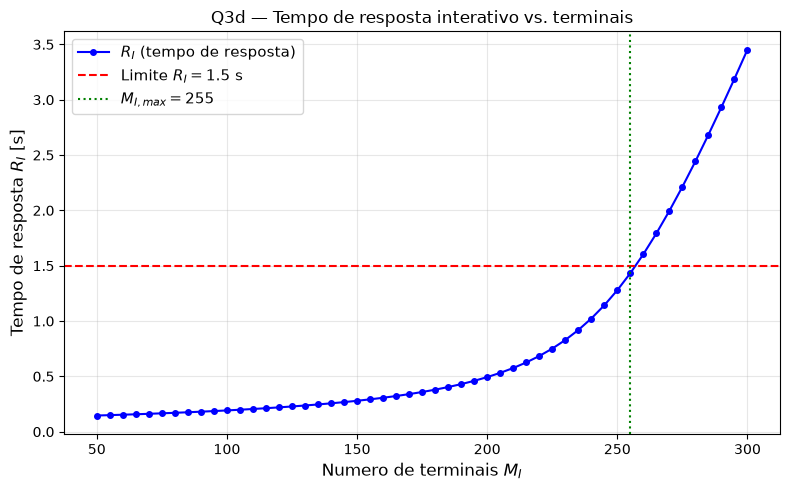

In [12]:
# 3d: varredura M_I = 50..300  (lambda_Q=5.85, CPU 2x mais rapida)
# Para populacoes grandes, pfqn_mvamx transborda (factorial(M) excede float64).
# Usa-se SolverMVA (line_solver): para redes mistas, o metodo padrao seleciona
# automaticamente o solver amvald (aproximado), que nao tem o problema de overflow.
M_range  = np.arange(50, 301, 5)
R_I_vals = []

for m in M_range:
    N_sw  = np.array([np.inf, np.inf, float(m)])
    stbl  = SolverMVA(_build_mixed_net(lam3b, L3_fastCPU, N_sw, Z3,
                                       snames=STATIONS)).getAvgSysTable()
    x_I   = float(stbl['SysTput'][2])
    R_I_vals.append(float(m / x_I - Z3[2]))

R_I_vals = np.array(R_I_vals)

# Maximo M_I com R_I < 1.5 s
threshold = 1.5
mask  = R_I_vals < threshold
M_max = int(M_range[mask][-1]) if mask.any() else 0
print(f"Maximo de terminais com R_I < {threshold} s:  M_I_max = {M_max}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(M_range, R_I_vals, 'b-o', markersize=4, label='$R_I$ (tempo de resposta)')
ax.axhline(threshold, color='r', linestyle='--', linewidth=1.5,
           label=f'Limite $R_I = {threshold}$ s')
if mask.any():
    ax.axvline(M_max, color='g', linestyle=':', linewidth=1.5,
               label=f'$M_{{I,max}} = {M_max}$')
ax.set_xlabel('Numero de terminais $M_I$', fontsize=12)
ax.set_ylabel('Tempo de resposta $R_I$ [s]', fontsize=12)
ax.set_title('Q3d — Tempo de resposta interativo vs. terminais', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3d_response_vs_terminals.png', dpi=120, bbox_inches='tight')
plt.show()
